In [1]:
import scanpy as scp
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from parameters import *

In [2]:
adata = scp.read("results/QC.h5ad")

# HVGs and PCs

In [3]:
scp.pp.highly_variable_genes(adata,flavor="seurat")
scp.pp.pca(adata,n_comps=100,use_highly_variable=True)

/opt/conda/lib/python3.8/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:>

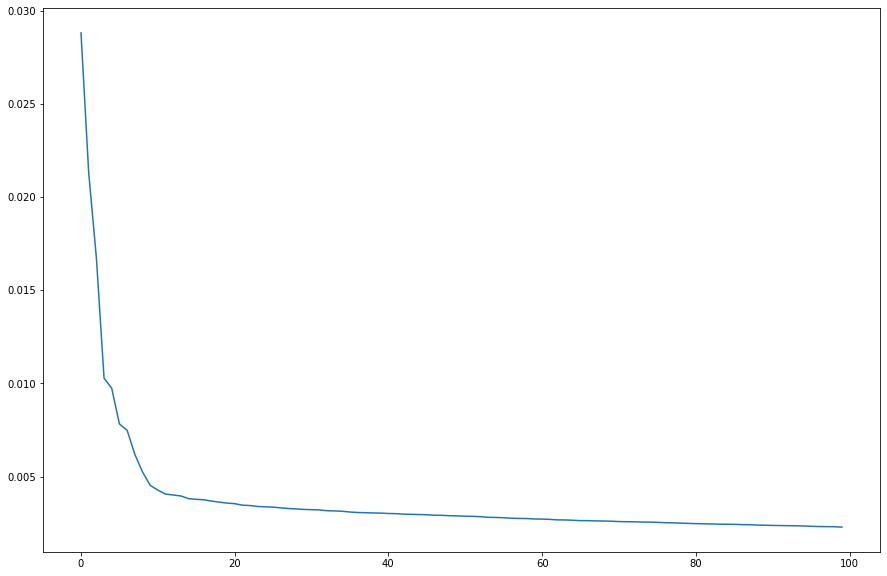

In [4]:
fig,ax = plt.subplots(figsize=[15,10])

sns.lineplot(range(100),y=adata.uns["pca"]["variance_ratio"],ax = ax)

In [5]:
scp.pp.pca(adata,n_comps=PCA,use_highly_variable=True)

In [6]:
adata.write("results/QC.h5ad")

# Projection by time

2021-10-06 13:50:31,965 - harmonypy - INFO - Iteration 1 of 10
2021-10-06 13:50:31,994 - harmonypy - INFO - Iteration 2 of 10
2021-10-06 13:50:32,002 - harmonypy - INFO - Converged after 2 iterations
2021-10-06 13:50:37,062 - harmonypy - INFO - Iteration 1 of 10
2021-10-06 13:50:37,103 - harmonypy - INFO - Iteration 2 of 10
2021-10-06 13:50:37,136 - harmonypy - INFO - Iteration 3 of 10
2021-10-06 13:50:37,177 - harmonypy - INFO - Converged after 3 iterations
2021-10-06 13:50:39,976 - harmonypy - INFO - Iteration 1 of 10
2021-10-06 13:50:40,000 - harmonypy - INFO - Iteration 2 of 10
2021-10-06 13:50:40,008 - harmonypy - INFO - Converged after 2 iterations
2021-10-06 13:50:41,777 - harmonypy - INFO - Iteration 1 of 10
2021-10-06 13:50:41,827 - harmonypy - INFO - Iteration 2 of 10
2021-10-06 13:50:41,867 - harmonypy - INFO - Iteration 3 of 10
2021-10-06 13:50:41,890 - harmonypy - INFO - Iteration 4 of 10
2021-10-06 13:50:41,904 - harmonypy - INFO - Converged after 4 iterations
2021-10-06 

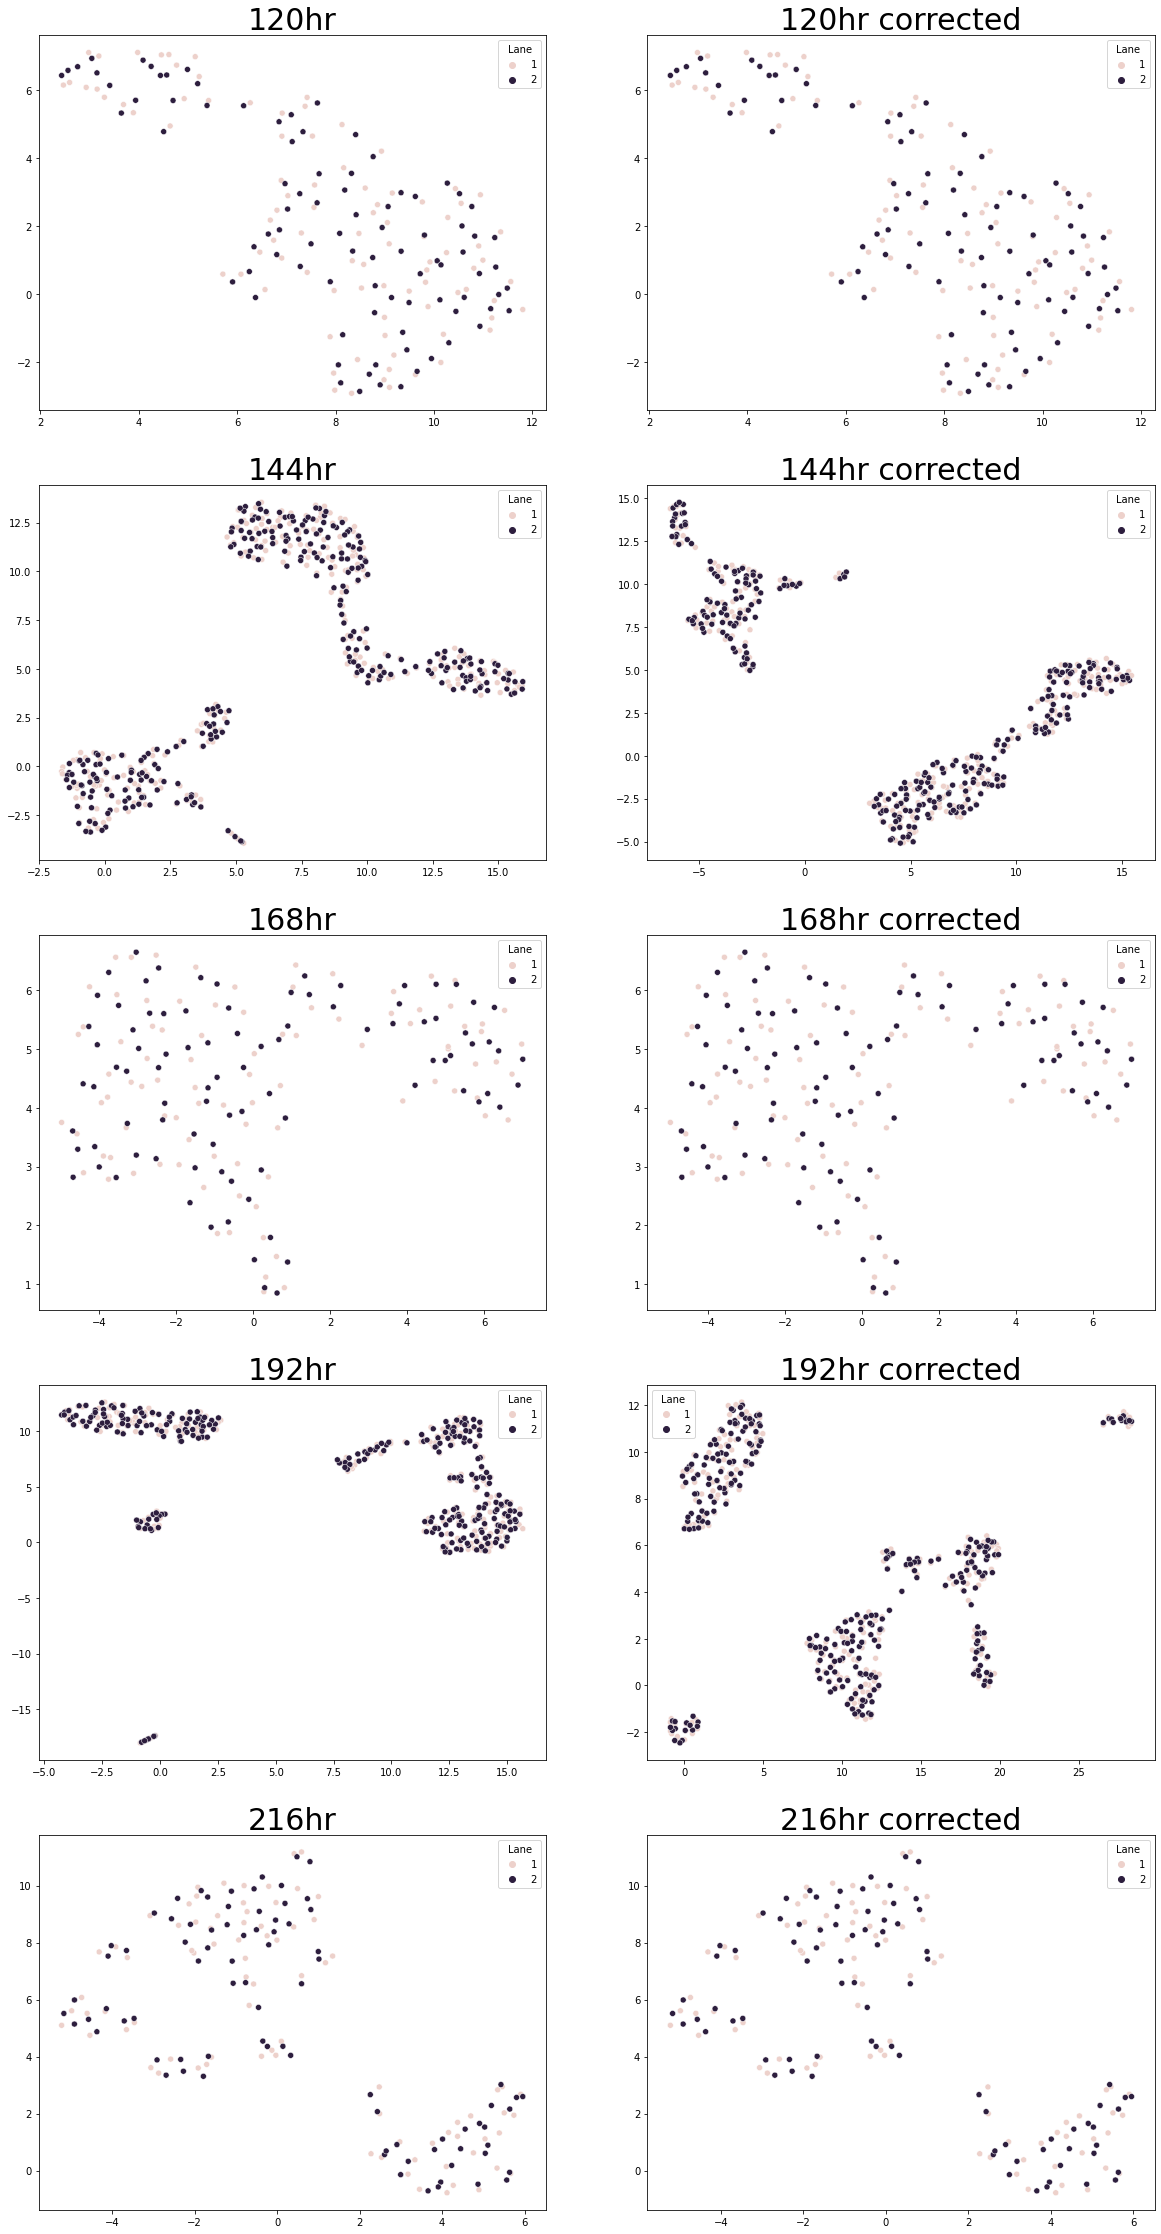

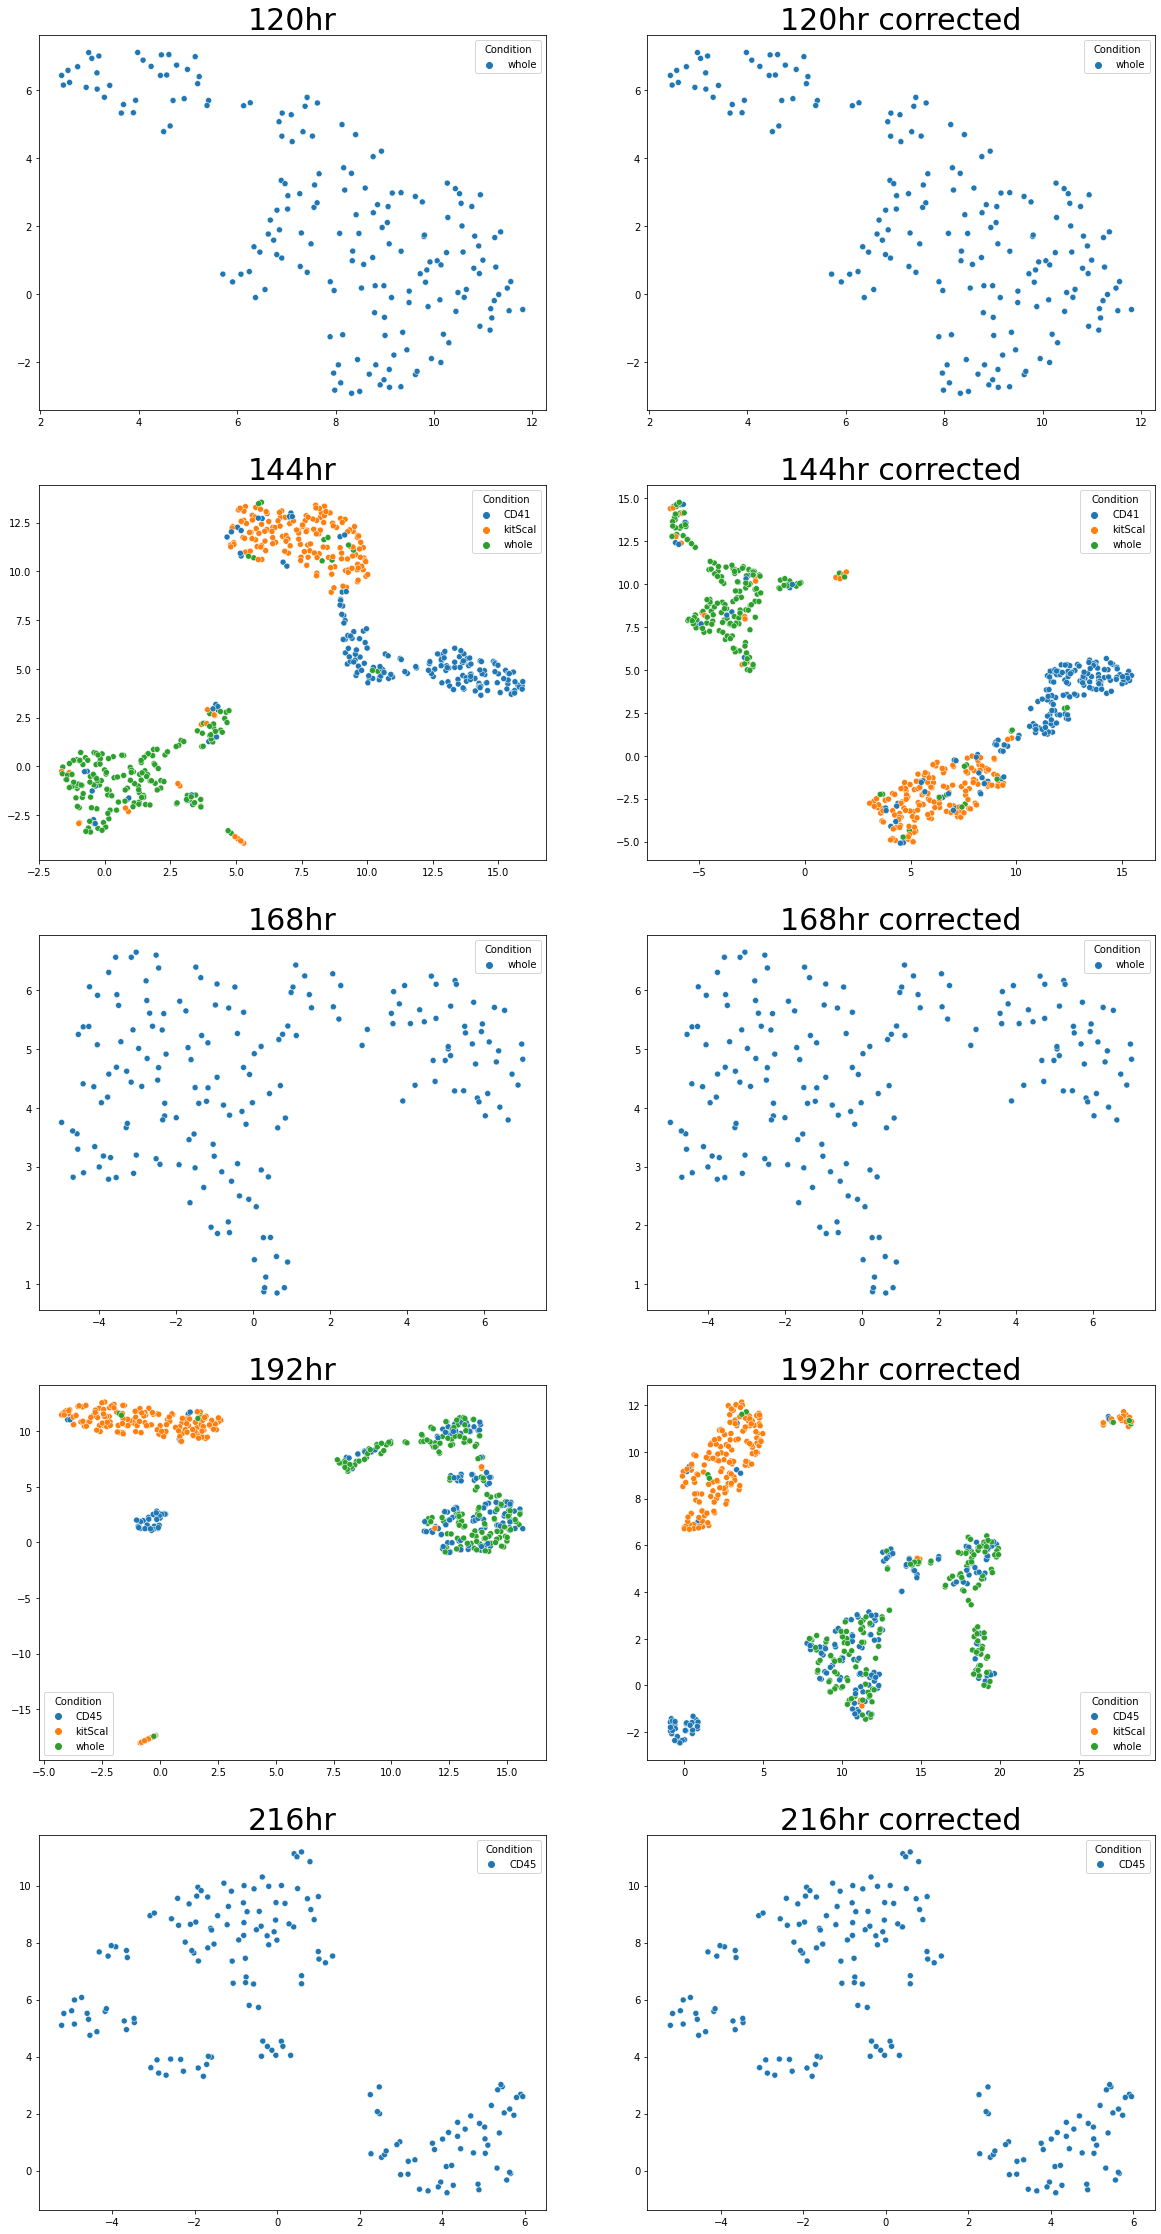

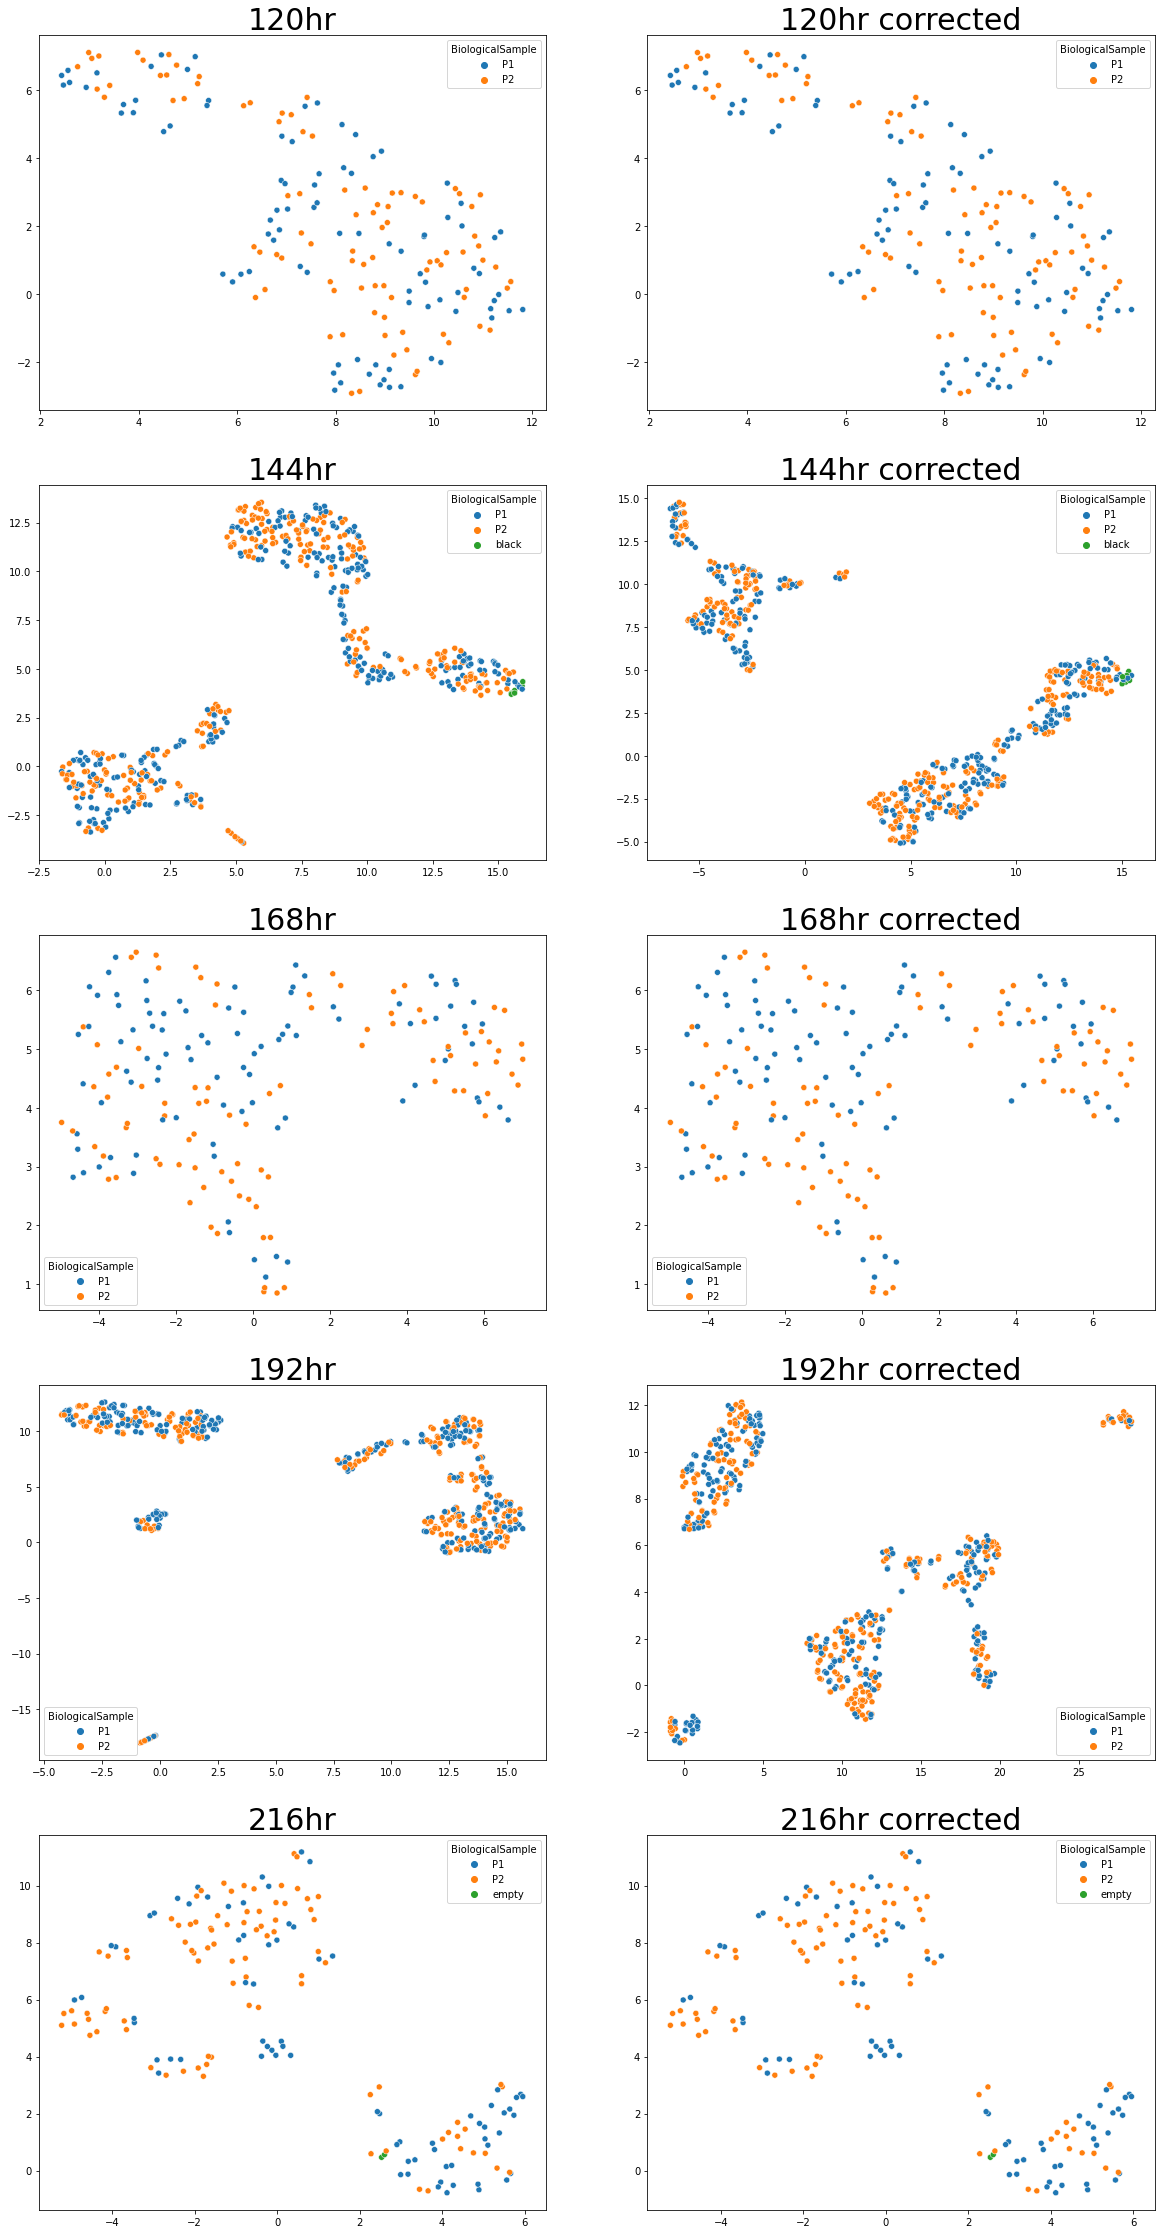

In [7]:
fig,ax = plt.subplots(5,2,figsize=[20,40])
fig2,ax2 = plt.subplots(5,2,figsize=[20,40])
fig3,ax3 = plt.subplots(5,2,figsize=[20,40])

for i,time in enumerate(np.sort(adata.obs["Time"].unique())):
    adataAux = adata[adata.obs["Time"]==time,:]
    
    scp.pp.pca(adata,n_comps=PCA,use_highly_variable=True)
    
    # Use batch correction before plots
    scp.external.pp.harmony_integrate(adataAux,key="Condition")
    scp.pp.neighbors(adataAux,use_rep="X_pca_harmony",metric="correlation",knn=20)
    scp.tl.umap(adataAux)
    
    adataAux.obsm["X_umap_corrected"] = adataAux.obsm["X_umap"]
    
    sns.scatterplot(x=adataAux.obsm["X_umap"][:,0],y=adataAux.obsm["X_umap"][:,1],hue=adataAux.obs["Lane"],ax=ax[i,1])
    ax[i,1].set_title(time+" corrected",fontsize=30)
    
    sns.scatterplot(x=adataAux.obsm["X_umap"][:,0],y=adataAux.obsm["X_umap"][:,1],hue=adataAux.obs["Condition"],ax=ax2[i,1])
    ax2[i,1].set_title(time+" corrected",fontsize=30)

    sns.scatterplot(x=adataAux.obsm["X_umap"][:,0],y=adataAux.obsm["X_umap"][:,1],hue=adataAux.obs["BiologicalSample"],ax=ax3[i,1])
    ax3[i,1].set_title(time+" corrected",fontsize=30)
    
    # Use raw correction with no batch correction at all
    scp.pp.neighbors(adataAux,metric="correlation",knn=20)
    scp.tl.umap(adataAux)
    
    sns.scatterplot(x=adataAux.obsm["X_umap"][:,0],y=adataAux.obsm["X_umap"][:,1],hue=adataAux.obs["Lane"],ax=ax[i,0])
    ax[i,0].set_title(time,fontsize=30)
    
    sns.scatterplot(x=adataAux.obsm["X_umap"][:,0],y=adataAux.obsm["X_umap"][:,1],hue=adataAux.obs["Condition"],ax=ax2[i,0])
    ax2[i,0].set_title(time,fontsize=30)

    sns.scatterplot(x=adataAux.obsm["X_umap"][:,0],y=adataAux.obsm["X_umap"][:,1],hue=adataAux.obs["BiologicalSample"],ax=ax3[i,0])
    ax3[i,0].set_title(time,fontsize=30)
    
    adataAux.write("results/dimensional_reduction_"+time+".h5ad")
        
fig.savefig("plots/UMAP_projection_Lane.png")
fig2.savefig("plots/UMAP_projection_Condition.png")
fig3.savefig("plots/UMAP_projection_BiologicalSample.png")

# Naive full projection

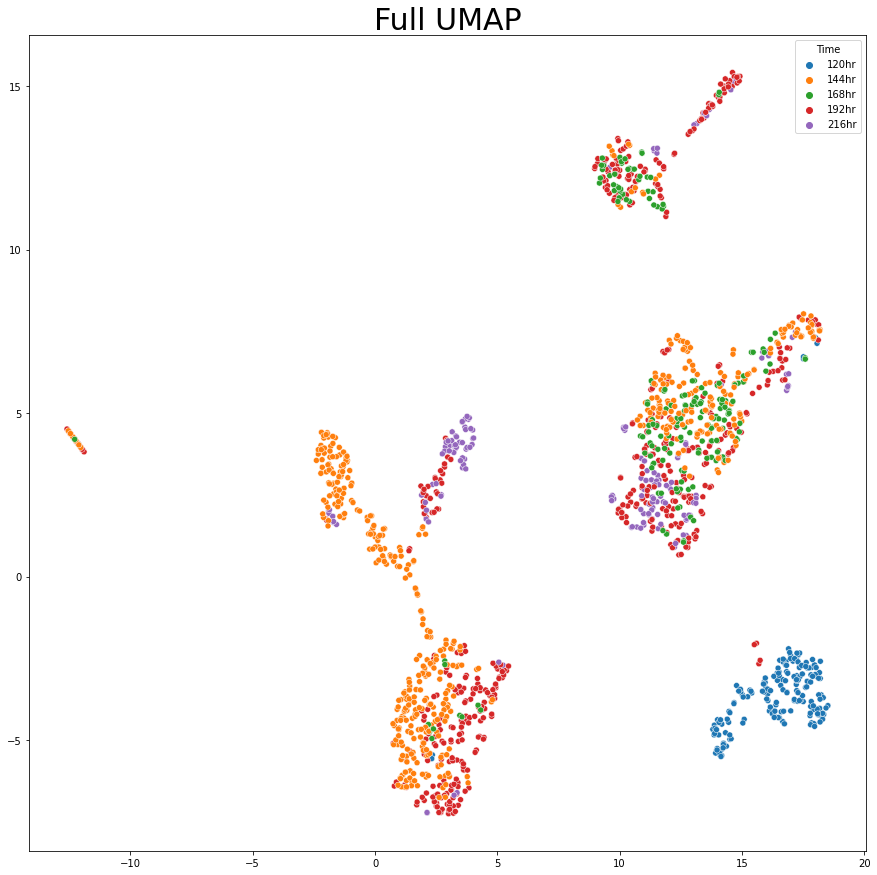

In [8]:
fig,ax = plt.subplots(1,1,figsize=[15,15])

scp.pp.neighbors(adata,metric="correlation",n_pcs=20,knn=20)
scp.tl.umap(adata)
    
sns.scatterplot(x=adata.obsm["X_umap"][:,0],y=adata.obsm["X_umap"][:,1],hue=adata.obs["Time"],ax=ax)
ax.set_title("Full UMAP",fontsize=30)

fig.savefig("plots/UMAP_projection_Time.png")

RUNNING SAM
Iteration: 0, Convergence: 1.0
Computing means and variances of genes.
Iteration: 1, Convergence: 0.7428997585912162
Iteration: 2, Convergence: 0.03302812532004053
Computing the UMAP embedding...
Elapsed time: 13.216612815856934 seconds


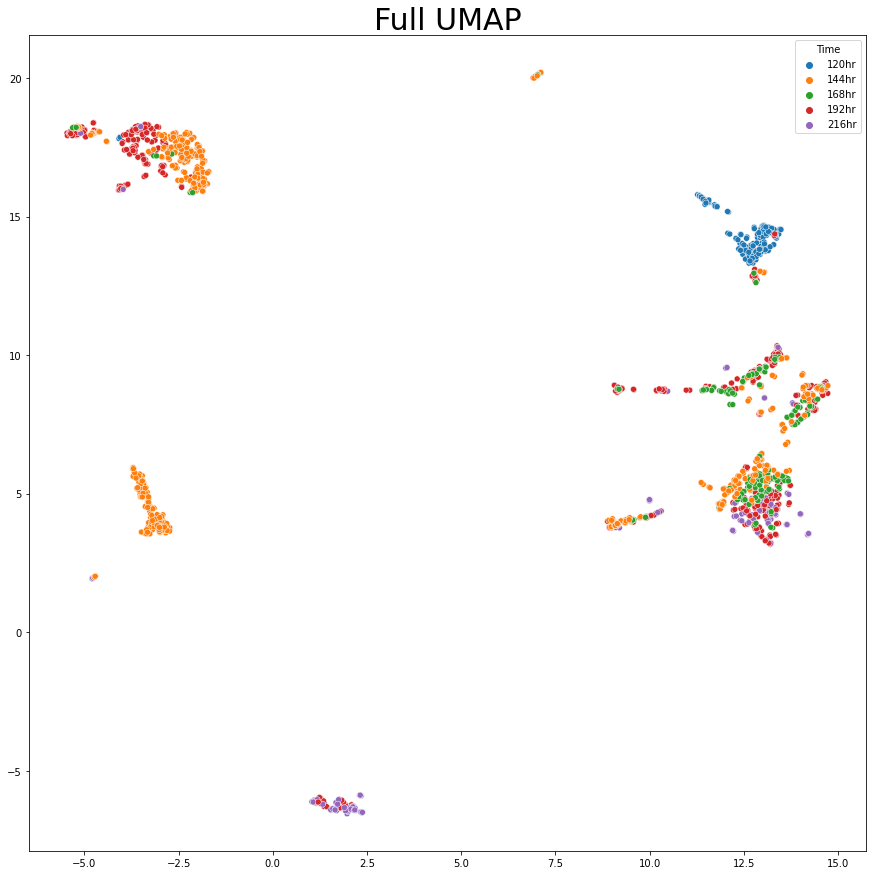

In [9]:
fig,ax = plt.subplots(1,1,figsize=[15,15])

scp.external.tl.sam(adata)

sns.scatterplot(x=adata.obsm["X_umap"][:,0],y=adata.obsm["X_umap"][:,1],hue=adata.obs["Time"],ax=ax)
ax.set_title("Full UMAP",fontsize=30)

fig.savefig("plots/SAM_UMAP_projection_Time.png")